In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('data/energydata_complete.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.head


<bound method NDFrame.head of                      Appliances  lights         T1       RH_1         T2  \
date                                                                       
2016-01-11 17:00:00          60      30  19.890000  47.596667  19.200000   
2016-01-11 17:10:00          60      30  19.890000  46.693333  19.200000   
2016-01-11 17:20:00          50      30  19.890000  46.300000  19.200000   
2016-01-11 17:30:00          50      40  19.890000  46.066667  19.200000   
2016-01-11 17:40:00          60      40  19.890000  46.333333  19.200000   
...                         ...     ...        ...        ...        ...   
2016-05-27 17:20:00         100       0  25.566667  46.560000  25.890000   
2016-05-27 17:30:00          90       0  25.500000  46.500000  25.754000   
2016-05-27 17:40:00         270      10  25.500000  46.596667  25.628571   
2016-05-27 17:50:00         420      10  25.500000  46.990000  25.414000   
2016-05-27 18:00:00         430      10  25.500000  46.600

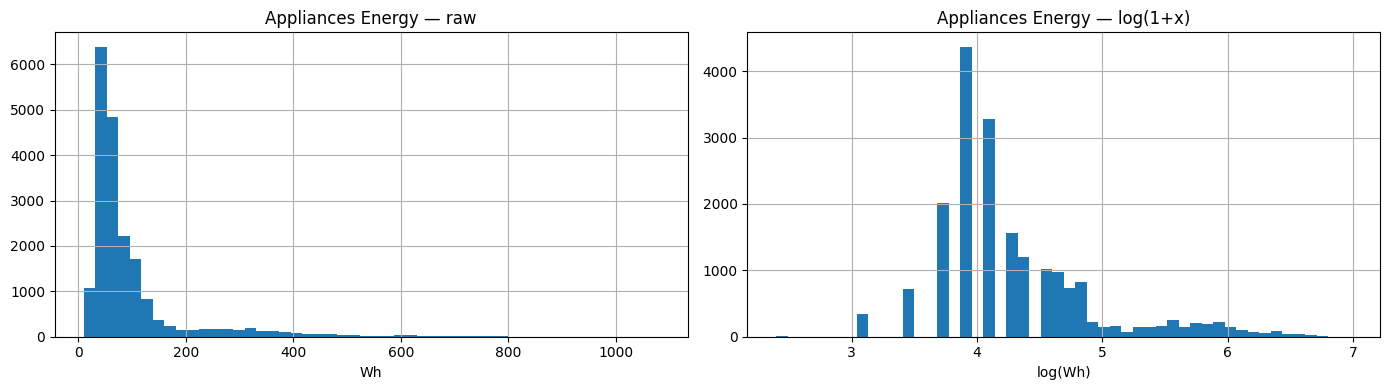

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64


In [5]:
# Appliances 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Appliances'].hist(bins=50, ax=axes[0])
axes[0].set_title('Appliances Energy — raw')
axes[0].set_xlabel('Wh')

np.log1p(df['Appliances']).hist(bins=50, ax=axes[1])
axes[1].set_title('Appliances Energy — log(1+x)')
axes[1].set_xlabel('log(Wh)')
plt.tight_layout()
plt.show()

print(df['Appliances'].describe())

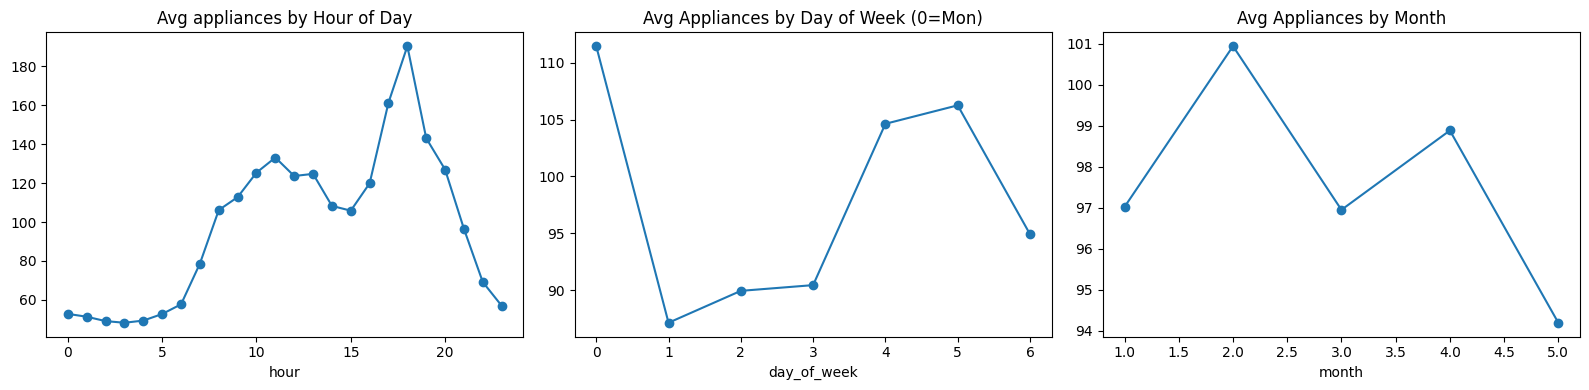

In [6]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

fig, axes = plt.subplots(1,3, figsize=(16,4))
df.groupby('hour')['Appliances'].mean().plot(ax=axes[0], marker='o')
axes[0].set_title('Avg appliances by Hour of Day')

df.groupby('day_of_week')['Appliances'].mean().plot(ax=axes[1], marker='o')
axes[1].set_title('Avg Appliances by Day of Week (0=Mon)')

df.groupby('month')['Appliances'].mean().plot(ax=axes[2], marker='o')
axes[2].set_title('Avg Appliances by Month')

plt.tight_layout()
plt.show()

Appliances     1.000000
T2             0.120073
T6             0.117638
T_out          0.099155
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
RH_4           0.016965
Tdewpoint      0.015353
T9             0.010010
RH_5           0.006955
Visibility     0.000230
rv1           -0.011145
rv2           -0.011145
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Name: Appliances, dtype: float64


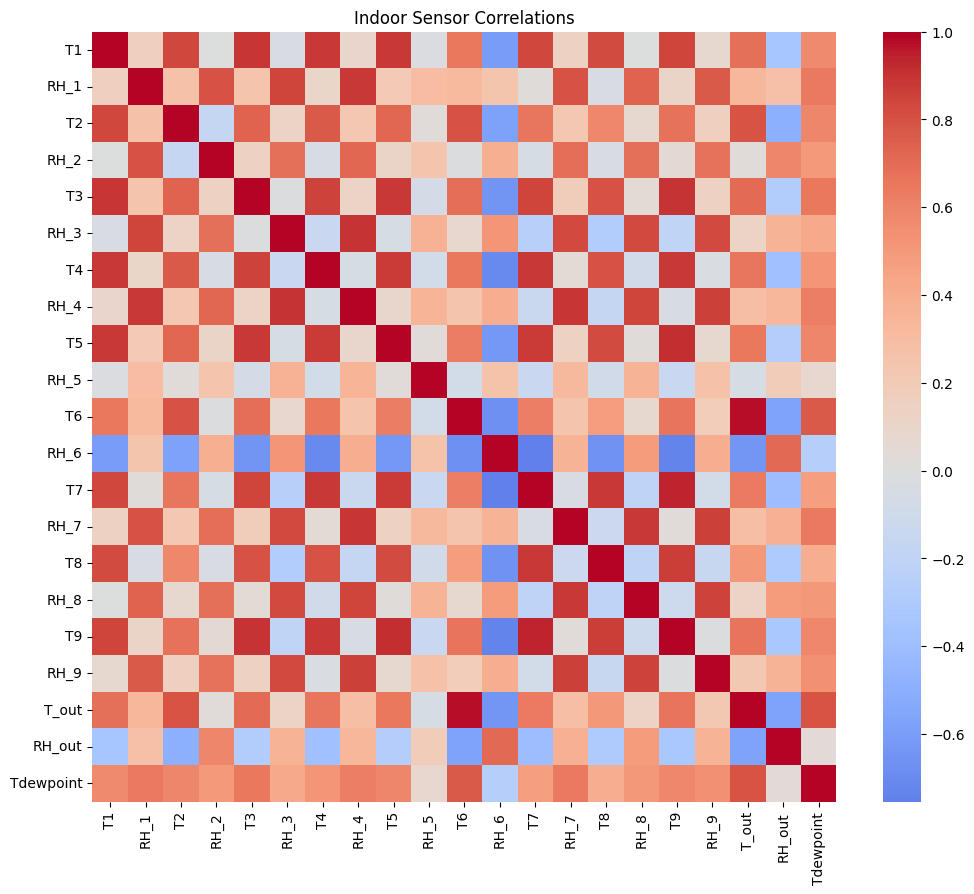

In [7]:
features = [c for c in df.columns if c not in ['lights', 'hour', 'day_of_week', 'month']]
corr = df[features].corr()['Appliances'].sort_values(ascending=False)
print(corr)

indoor_cols = [c for c in features if c.startswith('T') or c.startswith('RH')]
plt.figure(figsize=(12,10))
sns.heatmap(df[indoor_cols].corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Indoor Sensor Correlations')
plt.show()

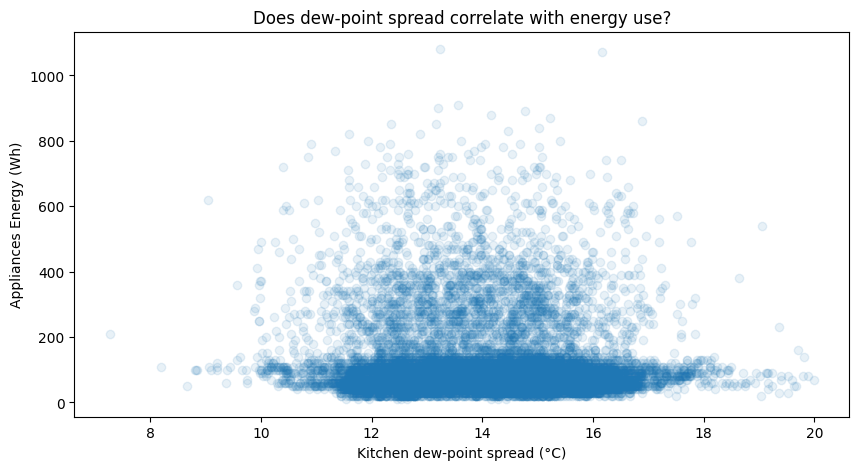

In [9]:
df['spread_out'] = df['T_out'] - df['Tdewpoint']

def calculate_dew_point(temp_c, rh_pct):
    A, B = 17.625, 243.04
    alpha = np.log(rh_pct / 100) + (A * temp_c) / (B + temp_c)
    return (B * alpha) / (A - alpha)
for i in range(1, 10):
    df[f'spread_{i}'] = df[f'T{i}'] - calculate_dew_point(df[f'T{i}'], df[f'RH_{i}'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['spread_1'], df['Appliances'], alpha=0.1)
ax.set_xlabel('Kitchen dew-point spread (°C)')
ax.set_ylabel('Appliances Energy (Wh)')
ax.set_title('Does dew-point spread correlate with energy use?')
plt.show()

In [10]:
print("rv1, rv2 — random variables (intentionally added noise):")
print(df[['rv1', 'rv2', 'Appliances']].corr())

rv1, rv2 — random variables (intentionally added noise):
                 rv1       rv2  Appliances
rv1         1.000000  1.000000   -0.011145
rv2         1.000000  1.000000   -0.011145
Appliances -0.011145 -0.011145    1.000000
